In [1]:
pip install ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 82.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [14]:
import os
from glob import glob
import random
import cv2
import matplotlib.pyplot as plt


In [22]:

rf = Roboflow(api_key="a1uozLDJeFIwfWwaSoy6")
project = rf.workspace("s-gbust").project("armed-person-recognition-gohff")
version = project.version(5)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Armed-Person-Recognition-5 in yolov8:: 100%|██████████| 7246/7246 [00:01<00:00, 4418.05it/s]


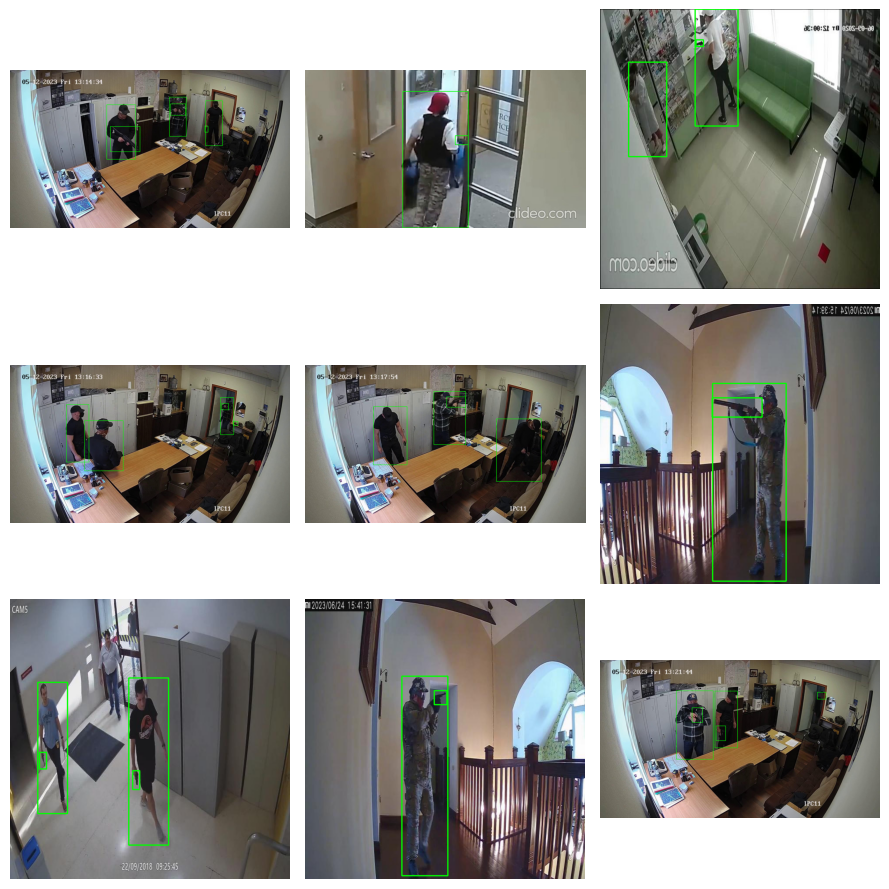

In [25]:
# =========================
# FUNGSI UTILITAS
# =========================
def load_yolo_boxes(label_path, img_w, img_h):
    boxes = []
    if not os.path.exists(label_path):
        return boxes

    with open(label_path, "r") as f:
        for line in f:
            cls, xc, yc, bw, bh = map(float, line.split())
            cls = int(cls)

            xc *= img_w
            yc *= img_h
            bw *= img_w
            bh *= img_h

            x_min = xc - bw/2
            y_min = yc - bh/2
            x_max = xc + bw/2
            y_max = yc + bh/2

            boxes.append([x_min, y_min, x_max, y_max, cls])

    return boxes


def draw_boxes(img, boxes):
    img = img.copy()
    for x_min, y_min, x_max, y_max, cls_id in boxes:
        x_min, y_min, x_max, y_max = map(int, [x_min, y_min, x_max, y_max])
        cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
    return img


# =========================
# CARI GAMBAR YANG ADA "person with a gun"
# =========================
candidates = []

for split in SPLITS:
    img_dir  = os.path.join(DATA_ROOT, split, "images")
    lbl_dir  = os.path.join(DATA_ROOT, split, "labels")

    for lbl_path in glob(os.path.join(lbl_dir, "*.txt")):
        labels_found = set()

        with open(lbl_path, "r") as f:
            for line in f:
                cls_id = int(float(line.split()[0]))
                if 0 <= cls_id < len(CLASS_NAMES):
                    labels_found.add(CLASS_NAMES[cls_id])

        # hanya ambil yang mengandung TARGET_LABEL
        if TARGET_LABEL not in labels_found:
            continue

        base = os.path.splitext(os.path.basename(lbl_path))[0]

        # cari file gambar
        for ext in ["jpg", "jpeg", "png"]:
            img_path = os.path.join(img_dir, base + "." + ext)
            if os.path.exists(img_path):
                candidates.append((img_path, lbl_path))
                break

# pastikan ada kandidat
if not candidates:
    raise ValueError(f"Tidak ada gambar dengan label '{TARGET_LABEL}' ditemukan.")


# pilih 9 gambar maksimal
random.shuffle(candidates)
selected = candidates[:9]


# =========================
# TAMPILKAN GRID 3x3 RAPIH
# =========================
plt.figure(figsize=(9, 9))

idx = 1
for img_path, lbl_path in selected:
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w, _ = img_rgb.shape

    boxes = load_yolo_boxes(lbl_path, w, h)
    img_draw = draw_boxes(img_rgb, boxes)

    plt.subplot(3, 3, idx)
    plt.imshow(img_draw)
    plt.axis("off")
    idx += 1

# matikan slot kosong jika <9
for empty in range(idx, 10):
    plt.subplot(3, 3, empty)
    plt.axis("off")

plt.tight_layout()
plt.show()

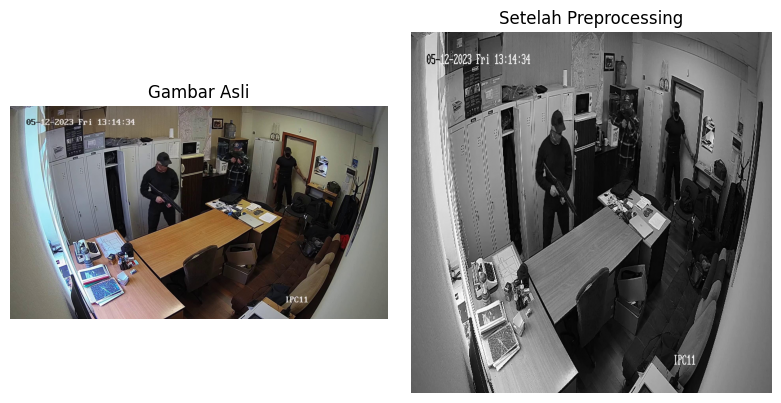

In [26]:
# ============================================
# TAMPILKAN SATU CONTOH: ASLI vs PREPROCESSING
# ============================================

# pakai salah satu gambar yang sudah terpilih di EDA (misal gambar pertama)
sample_img_path, sample_lbl_path = selected[0]

# baca gambar asli
img_bgr = cv2.imread(sample_img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# --------- PREPROCESSING ---------
# 1) konversi ke grayscale
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# 2) resize ke 640 x 640
TARGET_SIZE = 640
img_resized = cv2.resize(img_gray, (TARGET_SIZE, TARGET_SIZE))

# 3) normalisasi ke [0, 1]
img_norm = img_resized.astype("float32") / 255.0

# --------- VISUALISASI ---------
plt.figure(figsize=(8, 4))

# kiri: gambar asli (RGB)
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Gambar Asli")
plt.axis("off")

# kanan: setelah preprocessing (grayscale + resize + normalisasi)
plt.subplot(1, 2, 2)
plt.imshow(img_norm, cmap="gray")
plt.title("Setelah Preprocessing")
plt.axis("off")

plt.tight_layout()
plt.show()
